In [5]:
import numpy as np
import random

with open("numbers.txt", "w") as f:     #creates file with mode write #with is an easier way to open the file 
    for _ in range(10):
        a=random.randint(1,100)   #random integer
        b=random.randint(1, 100)
        f.write(f"{a},{b}\n")   #new line thing

# Load the two columns from the file
x, y = np.loadtxt("numbers.txt", delimiter= "," ,unpack=True)  #unpack is for it to be 2 arrays and delimiter is for the file to be read without the coma
print("x =", x)
print("y =", y)

# Ask user for file name
filename = input("Enter the file name: ")
# Load data from file
x, y = np.loadtxt(filename, delimiter=",", unpack=True)

# Statistics for x
print("x minimum:", x.min())
print("x maximum:", x.max())
print("x mean:", x.mean())

# Statistics for y
print("y minimum:", y.min())
print("y maximum:", y.max())
print("y mean:", y.mean())

# Median of y
y_med = np.median(y)
print("Median of y:", y_med)
# Calculate new array
y2 = (y - y_med)**2
print("y2 =", y2)

x = [16. 19.  3. 20. 93. 84. 54. 43. 97. 65.]
y = [37. 56. 93.  3. 16. 52. 27. 35. 17. 53.]


Enter the file name:  numbers.txt


x minimum: 3.0
x maximum: 97.0
x mean: 49.4
y minimum: 3.0
y maximum: 93.0
y mean: 38.9
Median of y: 36.0
y2 = [1.000e+00 4.000e+02 3.249e+03 1.089e+03 4.000e+02 2.560e+02 8.100e+01
 1.000e+00 3.610e+02 2.890e+02]


In [9]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.concatenate((a, b)))   #this makes a new array of the both together, so double size

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])    #these arrays just have two elements which have two elements inside, so smaller

print(np.concatenate((a, b)))
print( np.concatenate((a, b), axis=0))   #the fist two are the same cause the axis is 0 so does nothing
print(np.concatenate((a, b), axis=1))    # this one makes the first elements to be together and second ones too

[1 2 3 4 5 6]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


/tmp/ipykernel_2102639/2641174678.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread("m101BW.jpg")


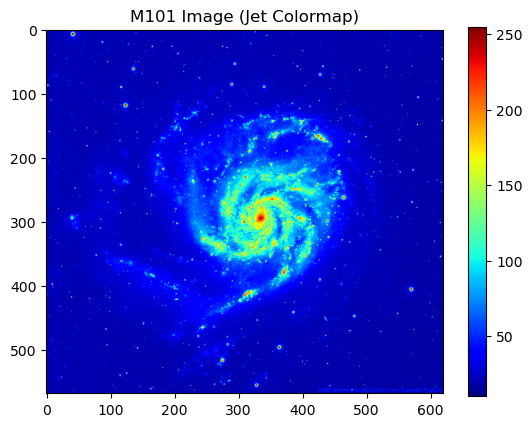

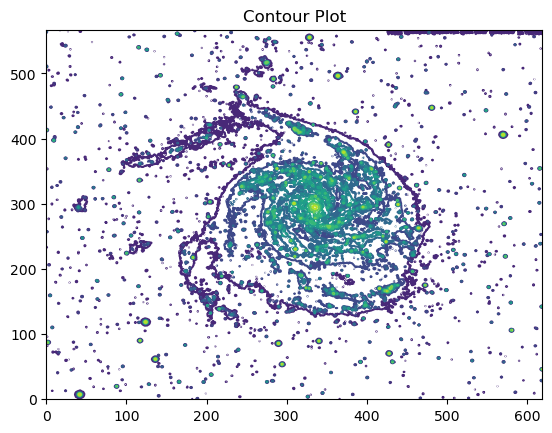

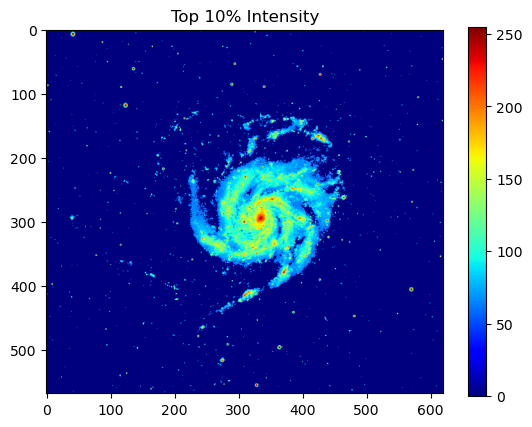

In [12]:
import imageio
import numpy as np
import matplotlib.pyplot as plt

# Read the image into a NumPy array
img = imageio.imread("m101BW.jpg")

# Plot the image using the jet color map
plt.figure()
plt.imshow(img, cmap="jet")
plt.colorbar()
plt.title("M101 Image (Jet Colormap)")
plt.show()

# Create a contour plot
plt.figure()
levels = np.linspace(img.min(), img.max(), 10)   # choose contour levels between the min, the max and does it 10 times
plt.contour(img, levels=levels)
plt.title("Contour Plot")
plt.show()

# keep only the highest 10% intensities, it only gives values above from it
filter = np.percentile(img, 90)

filtered_img = np.where(img >= filter, img, 0)

# Plot the filtered image
plt.figure()
plt.imshow(filtered_img, cmap="jet")
plt.colorbar()
plt.title("Top 10% Intensity")
plt.show()

Z-profile statistics at (x_mid, y_mid):
Max: 0.0606
Min: 0.00482
Sum: 0.89154
Mean: 0.0222885
Std Dev: 0.012699434544498428


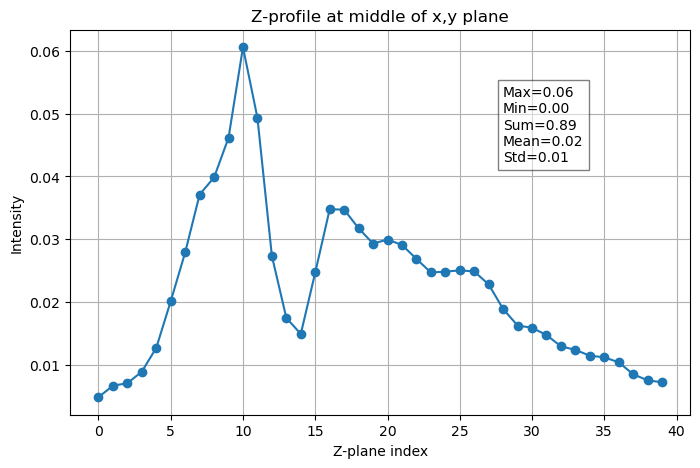

In [13]:
import numpy as np
import matplotlib.pyplot as plt

#Read ASCII data
data = np.loadtxt("ngc6946.txt")

# Original file is flat, so reshape to (z, y, x)
cube = data.reshape((40, 50, 70))

#Select a point near the middle of x and y
x_mid = 70 // 2  # middle column
y_mid = 50 // 2  # middle row

# Extract z-profile at this point
z_profile = cube[:, y_mid, x_mid]  # all z planes at (x_mid, y_mid)

print("Z-profile statistics at (x_mid, y_mid):")
print("Max:", z_profile.max())
print("Min:", z_profile.min())
print("Sum:", z_profile.sum())
print("Mean:", z_profile.mean())
print("Std Dev:", z_profile.std())

plt.figure(figsize=(8,5))
plt.plot(z_profile, marker='o', linestyle='-')
plt.xlabel("Z-plane index")
plt.ylabel("Intensity")
plt.title("Z-profile at middle of x,y plane")

stats_text = (f"Max={z_profile.max():.2f}\n"
              f"Min={z_profile.min():.2f}\n"
              f"Sum={z_profile.sum():.2f}\n"
              f"Mean={z_profile.mean():.2f}\n"
              f"Std={z_profile.std():.2f}")
plt.text(0.7*len(z_profile), z_profile.max()*0.7, stats_text, bbox=dict(facecolor='white', alpha=0.5))

plt.grid()
plt.show()

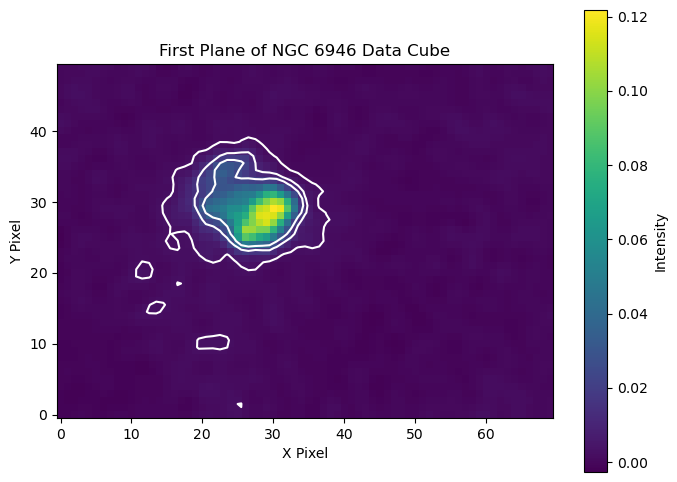

In [14]:
import numpy as np
import matplotlib.pyplot as plt

#Read ASCII data
data = np.loadtxt("ngc6946.txt")

# Original file is flat, so reshape to (z, y, x)
cube = data.reshape((40, 50, 70))

first_plane = cube[0]  #takes first plane along z-axis

# Calculate mean and standard deviation
mean_val = np.mean(first_plane)
std_val = np.std(first_plane)

# Plot the first plane
plt.figure(figsize=(8,6))
im = plt.imshow(first_plane, origin='lower', cmap='viridis')
plt.colorbar(im, label='Intensity')
plt.title('First Plane of NGC 6946 Data Cube')

# Overlay contours at mean, mean+std, mean+2*std
contour_levels = [mean_val, mean_val + std_val, mean_val + 2*std_val]
plt.contour(first_plane, levels=contour_levels, colors='white', origin='lower')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')

plt.show()

In [18]:
from scipy.constants import c as c_mps
class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    c= c_mps /1000
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        v=self.redshift() * self.c
        return v

my_galaxy = Galaxy("Andromeda", 4050.0)  #random example like andromeda

print(f"Galaxy Name: {my_galaxy.name}")
print(f"Velocity: {my_galaxy.velocity():.2f} km/s")    

Galaxy Name: Andromeda
Velocity: 6032.86 km/s


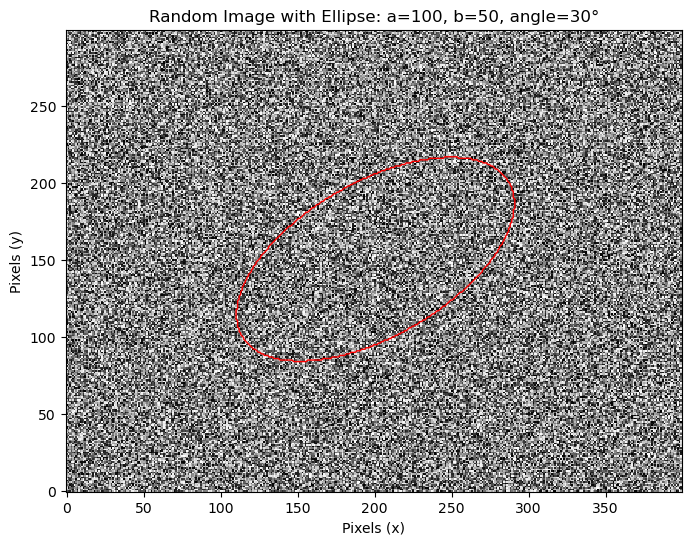

In [32]:
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))
fig, ax = plt.subplots(figsize=(8, 6))  # this defines ax

ax.imshow(data,interpolation='none', origin="lower", cmap='gray')


Nx, Ny = 400, 300
a = 100  # semi-major axis
b = 50   # semi-minor axis
theta = np.radians(30)  # Convert position angle to radians

#Create a coordinate grid centered at the middle
x = np.arange(Nx) - Nx / 2
y = np.arange(Ny) - Ny / 2
X, Y = np.meshgrid(x, y)

#rotation
X_rot = X * np.cos(theta) + Y * np.sin(theta)
Y_rot = -X * np.sin(theta) + Y * np.cos(theta)

ellipse_mask = (X_rot**2 / a**2) + (Y_rot**2 / b**2) <= 1

#ax for it to be in the same axes
ax.contour(ellipse_mask, colors='red', linewidths=1, origin="lower")
ax.set_title(f"Random Image with Ellipse: a={a}, b={b}, angle=30°")
ax.set_xlabel("Pixels (x)")
ax.set_ylabel("Pixels (y)")

plt.show()